In [58]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [59]:
df = pd.read_csv("Salary_dataset.csv")

In [60]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [61]:
df = df.drop(df.columns[0] , axis = 1)

In [62]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [63]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


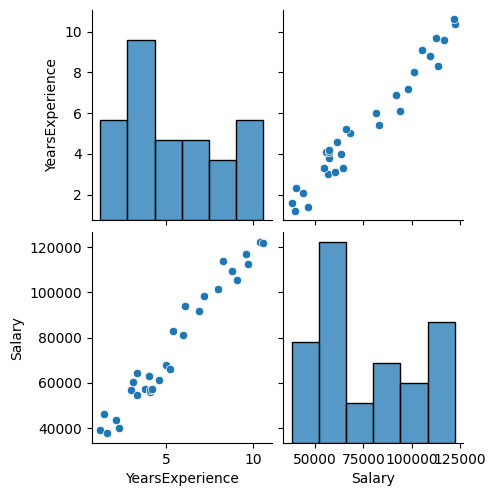

In [64]:
sns.pairplot(df)

Regplot:- this plot a best fit line and the shadow part is the variation or for fine tuning

<Axes: xlabel='YearsExperience', ylabel='Salary'>

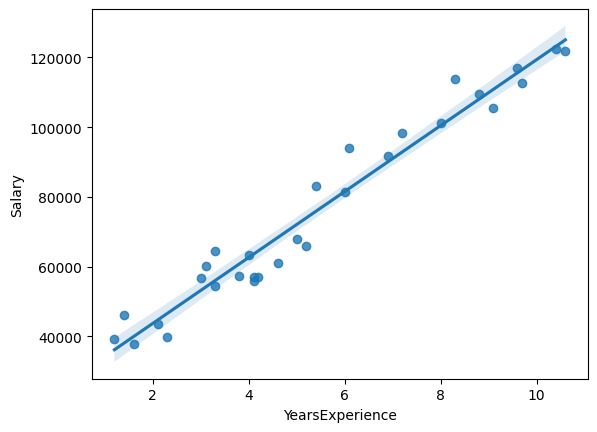

In [65]:
sns.regplot(x='YearsExperience', y='Salary', data=df)

seperate dependent and independent feature

In [66]:
X = df[["YearsExperience"]]
y = df['Salary']

In [67]:
X.head()

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3


In [68]:
y

0      39344.0
1      46206.0
2      37732.0
3      43526.0
4      39892.0
5      56643.0
6      60151.0
7      54446.0
8      64446.0
9      57190.0
10     63219.0
11     55795.0
12     56958.0
13     57082.0
14     61112.0
15     67939.0
16     66030.0
17     83089.0
18     81364.0
19     93941.0
20     91739.0
21     98274.0
22    101303.0
23    113813.0
24    109432.0
25    105583.0
26    116970.0
27    112636.0
28    122392.0
29    121873.0
Name: Salary, dtype: float64

In [69]:
from sklearn.model_selection import train_test_split
X_train , X_test ,y_train , y_test  = train_test_split(X,y,test_size=0.25 , random_state=42)

In [70]:
X_test

,YearsExperience
27,9.7
15,5.0
23,8.3
17,5.4
8,3.3
9,3.8
28,10.4
24,8.8


In [71]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [72]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [73]:
X_test

array([[ 1.79640106],
       [ 0.03908914],
       [ 1.27294644],
       [ 0.1886476 ],
       [-0.59653431],
       [-0.40958624],
       [ 2.05812836],
       [ 1.45989452]])

In [74]:
from sklearn.linear_model  import LinearRegression

In [75]:
regression  = LinearRegression(n_jobs= -1)
regression.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [79]:
print("coefficient or slope: ", regression.coef_)
print("Intercept: ", regression.intercept_)

coefficient or slope:  [25063.1519945]
Intercept:  70417.40909090909


In [77]:
y_pred = regression.predict(X_test)

In [78]:
y_pred

array([115440.88180109,  71397.10622651, 102321.45928951,  75145.51265839,
        55466.37889103,  60151.88693088, 122000.59305688, 107006.96732936])

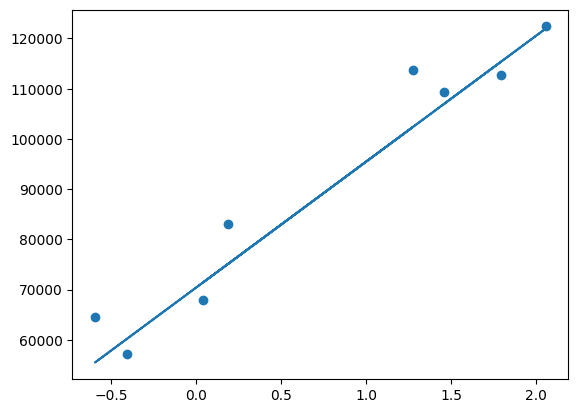

In [81]:
plt.scatter(X_test , y_test)
plt.plot(X_test , y_pred)

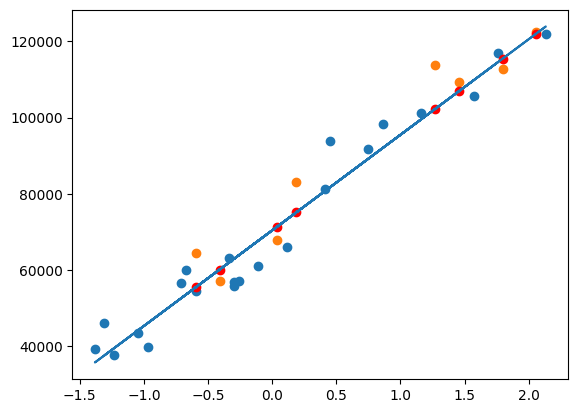

In [82]:
plt.scatter(X_train , y_train )
plt.plot(X_train , regression.predict(X_train))
plt.scatter(X_test , y_test)
plt.scatter(X_test , y_pred , color = 'red')

In [83]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [87]:
mse  =mean_squared_error(y_test , y_pred)
mae = mean_absolute_error(y_test , y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

38802588.99247059
5056.9954666635895
6229.172416338352


In [88]:
from sklearn.metrics import r2_score

In [89]:
score=r2_score(y_test,y_pred)
print(score)

0.9347210011126783


In [97]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.9238411679647913

In [100]:
import statsmodels.api as sm
model = sm.OLS(y_train , X_train).fit()

In [101]:
prediction = model.predict(X_test)

In [102]:
prediction

array([ 45023.47271018,    979.6971356 ,  31904.0501986 ,   4728.10356748,
       -14951.03019988, -10265.52216003,  51583.18396597,  36589.55823845])

In [104]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Salary   R-squared (uncentered):                   0.112
Model:                            OLS   Adj. R-squared (uncentered):              0.070
Method:                 Least Squares   F-statistic:                              2.645
Date:                Thu, 12 Mar 2026   Prob (F-statistic):                       0.119
Time:                        15:53:28   Log-Likelihood:                         -276.85
No. Observations:                  22   AIC:                                      555.7
Df Residuals:                      21   BIC:                                      556.8
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------